In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("processed_caltech.csv")

In [3]:
df['connectionTime'] = pd.to_datetime(df['connectionTime'])

df['hour'] = df['connectionTime'].dt.hour
df['day_of_week'] = df['connectionTime'].dt.dayofweek
df['month'] = df['connectionTime'].dt.month
df['date'] = df['connectionTime'].dt.date

In [4]:
hourly_df = (
    df.groupby(
        ['date','hour']
    )
    .size()
    .reset_index(name='demand')
)

In [5]:
hourly_df['date'] = pd.to_datetime(
    hourly_df['date']
)

hourly_df['day_of_week'] = (
    hourly_df['date'].dt.dayofweek
)

hourly_df['month'] = (
    hourly_df['date'].dt.month
)

hourly_df['day'] = (
    hourly_df['date'].dt.day
)

In [6]:
hourly_df.head()

,date,hour,demand,day_of_week,month,day
0,2018-04-25,11,1,2,4,25
1,2018-04-25,13,2,2,4,25
2,2018-04-25,14,5,2,4,25
3,2018-04-25,15,15,2,4,25
4,2018-04-25,16,8,2,4,25


In [7]:
X = hourly_df[
    [
        'hour',
        'day_of_week',
        'month',
        'day'
    ]
]

y = hourly_df['demand']

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )
)

In [9]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [10]:
predictions = rf.predict(
    X_test
)

In [11]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    y_test,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

r2 = r2_score(
    y_test,
    predictions
)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 1.3801190476190477
RMSE: 1.9481527703935284
R2  : 0.7795616388992993


In [1]:
hourly_df = (
    df.groupby(['date','hour'])
      .size()
      .reset_index(name='demand')
)

NameError: name 'df' is not defined

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("processed_caltech.csv")

In [3]:
df['connectionTime'] = pd.to_datetime(df['connectionTime'])

df['hour'] = df['connectionTime'].dt.hour
df['day_of_week'] = df['connectionTime'].dt.dayofweek
df['month'] = df['connectionTime'].dt.month
df['day'] = df['connectionTime'].dt.day
df['date'] = df['connectionTime'].dt.date

In [4]:
hourly_df = (
    df.groupby(['date','hour'])
      .size()
      .reset_index(name='demand')
)

In [5]:
print(df.shape)

(14974, 21)


In [6]:
hourly_df['date'] = pd.to_datetime(hourly_df['date'])

hourly_df = hourly_df.sort_values(
    ['date', 'hour']
)

hourly_df = hourly_df.reset_index(
    drop=True
)

In [7]:
hourly_df['lag_1'] = hourly_df['demand'].shift(1)

hourly_df['lag_2'] = hourly_df['demand'].shift(2)

hourly_df['lag_24'] = hourly_df['demand'].shift(24)

In [8]:
hourly_df['rolling_3'] = (
    hourly_df['demand']
    .rolling(3)
    .mean()
)

hourly_df['rolling_24'] = (
    hourly_df['demand']
    .rolling(24)
    .mean()
)

In [9]:
hourly_df = hourly_df.dropna()

In [10]:
hourly_df.head()

,date,hour,demand,lag_1,lag_2,lag_24,rolling_3,rolling_24
24,2018-04-26,20,2,1.0,1.0,1.0,1.333333,3.958333
25,2018-04-26,21,2,2.0,1.0,2.0,1.666667,3.958333
26,2018-04-26,23,1,2.0,2.0,5.0,1.666667,3.791667
27,2018-04-27,1,4,1.0,2.0,15.0,2.333333,3.333333
28,2018-04-27,2,1,4.0,1.0,8.0,2.000000,3.041667


In [11]:
X = hourly_df[
[
    'hour',
    'lag_1',
    'lag_2',
    'lag_24',
    'rolling_3',
    'rolling_24'
]
]

y = hourly_df['demand']

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [13]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [14]:
predictions = rf.predict(X_test)

In [15]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(y_test, predictions)

rmse = np.sqrt(
    mean_squared_error(y_test, predictions)
)

r2 = r2_score(y_test, predictions)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 0.2971034311598506
RMSE: 0.7273626911866348
R2  : 0.9605010421276166


In [16]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

In [17]:
xgb.fit(
    X_train,
    y_train
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [18]:
xgb_predictions = xgb.predict(
    X_test
)

In [19]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(
    y_test,
    xgb_predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_predictions
    )
)

r2 = r2_score(
    y_test,
    xgb_predictions
)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 0.33252570033073425
RMSE: 0.6834914648643533
R2  : 0.9651221632957458


In [20]:
hourly_df['lag_48'] = hourly_df['demand'].shift(48)
hourly_df['lag_72'] = hourly_df['demand'].shift(72)
hourly_df['lag_168'] = hourly_df['demand'].shift(168)

hourly_df['rolling_6'] = hourly_df['demand'].rolling(6).mean()
hourly_df['rolling_12'] = hourly_df['demand'].rolling(12).mean()
hourly_df['rolling_48'] = hourly_df['demand'].rolling(48).mean()

hourly_df = hourly_df.dropna()

In [21]:
features = [
    'hour',
    'lag_1',
    'lag_2',
    'lag_24',
    'lag_48',
    'lag_72',
    'lag_168',
    'rolling_3',
    'rolling_6',
    'rolling_12',
    'rolling_24',
    'rolling_48'
]

X = hourly_df[features]
y = hourly_df['demand']

In [22]:
split = int(len(hourly_df) * 0.8)

train = hourly_df.iloc[:split]
test = hourly_df.iloc[split:]

X_train = train[features]
y_train = train['demand']

X_test = test[features]
y_test = test['demand']

In [23]:
from catboost import CatBoostRegressor

cat = CatBoostRegressor(
    iterations=3000,
    depth=8,
    learning_rate=0.03,
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    verbose=200
)

cat.fit(
    X_train,
    y_train,
    eval_set=(X_test, y_test)
)

0:	learn: 3.7412471	test: 3.5340012	best: 3.5340012 (0)	total: 92.4ms	remaining: 4m 37s
200:	learn: 0.7441396	test: 1.0489827	best: 1.0489827 (200)	total: 1.29s	remaining: 17.9s
400:	learn: 0.4465350	test: 0.8773286	best: 0.8770279 (399)	total: 2.62s	remaining: 17s
600:	learn: 0.2973812	test: 0.7811335	best: 0.7811335 (600)	total: 3.68s	remaining: 14.7s
800:	learn: 0.2148739	test: 0.7313637	best: 0.7312892 (797)	total: 4.76s	remaining: 13.1s
1000:	learn: 0.1596381	test: 0.6976923	best: 0.6976575 (999)	total: 5.86s	remaining: 11.7s
1200:	learn: 0.1227812	test: 0.6769465	best: 0.6769465 (1200)	total: 6.96s	remaining: 10.4s
1400:	learn: 0.0958177	test: 0.6620122	best: 0.6620122 (1400)	total: 8.04s	remaining: 9.18s
1600:	learn: 0.0767460	test: 0.6544207	best: 0.6543825 (1599)	total: 9.12s	remaining: 7.97s
1800:	learn: 0.0625292	test: 0.6489346	best: 0.6489346 (1800)	total: 10.5s	remaining: 7s
2000:	learn: 0.0519834	test: 0.6452077	best: 0.6452051 (1999)	total: 11.9s	remaining: 5.92s
2200:	

CatBoostRegressor(depth=8, eval_metric='RMSE', iterations=3000, learning_rate=0.03, loss_function='RMSE', random_seed=42, verbose=200)

In [24]:
cat_pred = cat.predict(X_test)

In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, cat_pred)
rmse = np.sqrt(mean_squared_error(y_test, cat_pred))
r2 = r2_score(y_test, cat_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 0.25139618805713976
RMSE: 0.6377750881100471
R2  : 0.9678297889440446


In [26]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': cat.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
7,rolling_3,45.093610
0,hour,19.609981
2,lag_2,18.774893
1,lag_1,11.283139
9,rolling_12,1.998059
8,rolling_6,1.706255
11,rolling_48,0.335117
10,rolling_24,0.330464
6,lag_168,0.301105
5,lag_72,0.290165


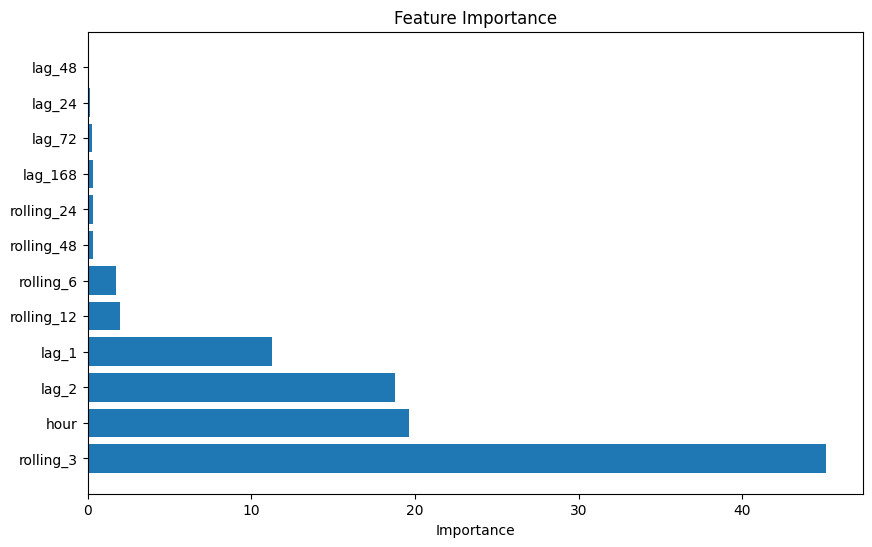

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    importance['Feature'],
    importance['Importance']
)

plt.title("Feature Importance")
plt.xlabel("Importance")

plt.show()

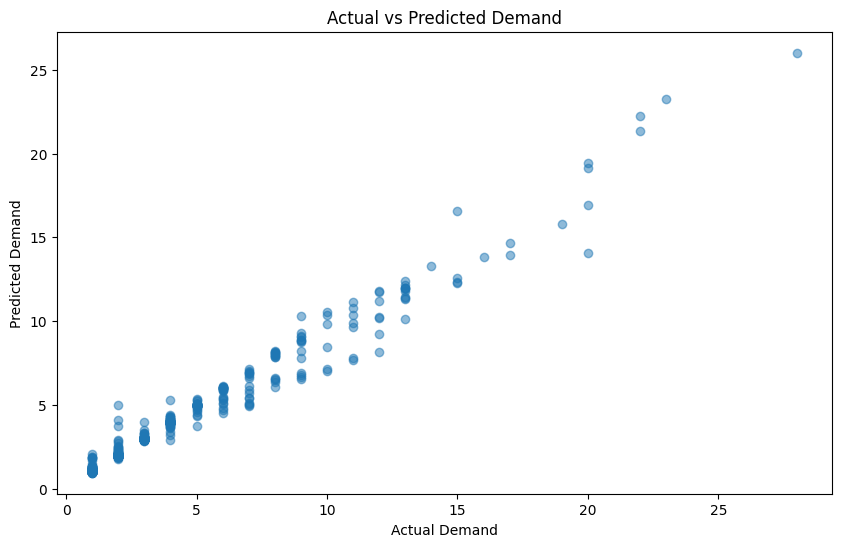

In [28]:
plt.figure(figsize=(10,6))

plt.scatter(
    y_test,
    cat_pred,
    alpha=0.5
)

plt.xlabel("Actual Demand")
plt.ylabel("Predicted Demand")
plt.title("Actual vs Predicted Demand")

plt.show()

In [1]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    cat_pred,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Actual Demand")
plt.ylabel("Predicted Demand")
plt.title("Actual vs Predicted Demand")

plt.tight_layout()
plt.show()

NameError: name 'y_test' is not defined

<Figure size 800x600 with 0 Axes>

In [2]:
print(type(X_test))
print(type(y_test))
print(type(cat_pred))

NameError: name 'X_test' is not defined

In [3]:
cat.fit(X_train, y_train)

NameError: name 'cat' is not defined

In [5]:
cat_pred = cat.predict(X_test)

NameError: name 'cat' is not defined

In [6]:
print(X.shape)
print(y.shape)

NameError: name 'X' is not defined

In [7]:
import pandas as pd

df = pd.read_csv("processed_caltech.csv")

In [8]:
df['connectionTime'] = pd.to_datetime(df['connectionTime'])

df['hour'] = df['connectionTime'].dt.hour
df['date'] = df['connectionTime'].dt.date

In [9]:
hourly_df = (
    df.groupby(['date','hour'])
      .size()
      .reset_index(name='demand')
)

In [10]:
hourly_df['lag_1'] = hourly_df['demand'].shift(1)
hourly_df['lag_2'] = hourly_df['demand'].shift(2)
hourly_df['lag_24'] = hourly_df['demand'].shift(24)

hourly_df['rolling_3'] = (
    hourly_df['demand']
    .rolling(3)
    .mean()
)

hourly_df['rolling_24'] = (
    hourly_df['demand']
    .rolling(24)
    .mean()
)

hourly_df = hourly_df.dropna()

In [11]:
X = hourly_df[
    [
        'hour',
        'lag_1',
        'lag_2',
        'lag_24',
        'rolling_3',
        'rolling_24'
    ]
]

y = hourly_df['demand']

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [13]:
from catboost import CatBoostRegressor

cat = CatBoostRegressor(
    iterations=3000,
    learning_rate=0.03,
    depth=8,
    loss_function='RMSE',
    random_seed=42,
    verbose=False
)

cat.fit(X_train, y_train)

CatBoostRegressor(depth=8, iterations=3000, learning_rate=0.03, loss_function='RMSE', random_seed=42, verbose=False)

In [14]:
cat_pred = cat.predict(X_test)

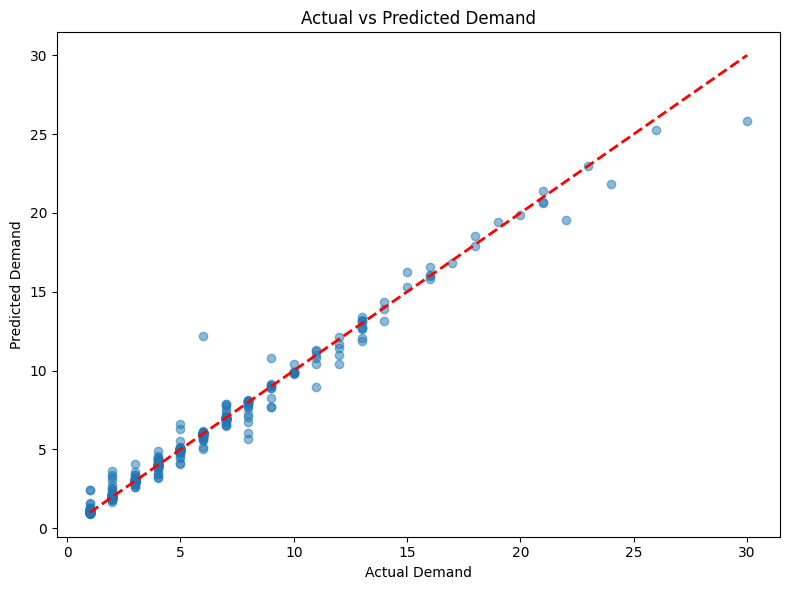

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    cat_pred,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Actual Demand")
plt.ylabel("Predicted Demand")
plt.title("Actual vs Predicted Demand")

plt.tight_layout()
plt.show()

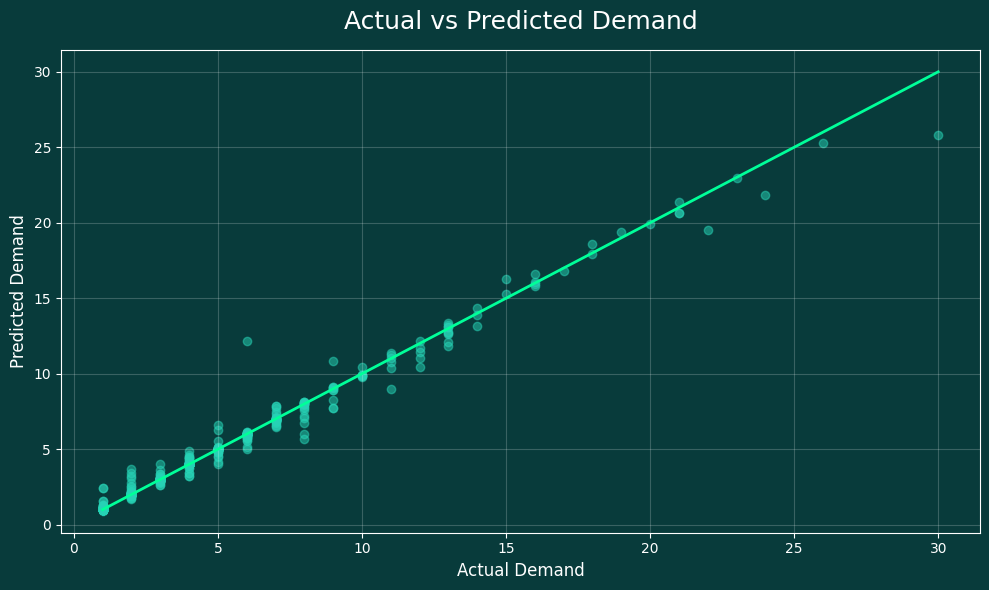

In [17]:
import matplotlib.pyplot as plt

plt.style.use('dark_background')

fig, ax = plt.subplots(figsize=(10,6))

ax.scatter(
    y_test,
    cat_pred,
    alpha=0.5,
    color='#27d3b6'
)

ax.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='#00ff99',
    linewidth=2
)

ax.set_title(
    "Actual vs Predicted Demand",
    fontsize=18,
    color='white',
    pad=15
)

ax.set_xlabel(
    "Actual Demand",
    fontsize=12,
    color='white'
)

ax.set_ylabel(
    "Predicted Demand",
    fontsize=12,
    color='white'
)

ax.set_facecolor('#083b3b')
fig.patch.set_facecolor('#083b3b')

ax.grid(
    alpha=0.2,
    color='white'
)

plt.tight_layout()

plt.savefig(
    "catboost_performance.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()
